# 📈 Notebook 10: Statistical Parameters & Custom Aggregations

## 🎯 Learning Objectives

- Understand the `estimator` parameter across plot types
- Master confidence interval options (`ci`, `sd`, `se`, `pi`)
- Create custom estimator functions
- Use `errorbar` parameter effectively
- Compare bootstrap vs parametric confidence intervals
- Add statistical annotations to plots

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import sys
sys.path.append('../')
from utils.plot_utils import apply_theme, save_fig, stylize_plot

apply_theme()
print('✅ Libraries imported')

✅ Libraries imported


In [2]:
# Load data
tips = sns.load_dataset('tips')
employee_df = pd.read_csv('../datasets/employee_data.csv')
print(f'Tips: {tips.shape}, Employee: {employee_df.shape}')

Tips: (244, 7), Employee: (150, 4)


## 1️⃣ The `estimator` Parameter

**Which plots use `estimator`?**
- `barplot()`
- `pointplot()`
- `lineplot()` (when multiple observations per x value)

**Common estimators:**
- `np.mean` (default)
- `np.median`
- `np.sum`
- `np.std`
- `len` (count)
- Custom functions

/var/folders/b1/_jgsd68x1ll8qj42cvtdmyvh0000gn/T/ipykernel_52921/3679237160.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='day', y='total_bill', estimator=np.mean, ax=axes[0,0], palette='Blues_d')
/var/folders/b1/_jgsd68x1ll8qj42cvtdmyvh0000gn/T/ipykernel_52921/3679237160.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='day', y='total_bill', estimator=np.median, ax=axes[0,1], palette='Greens_d')
/var/folders/b1/_jgsd68x1ll8qj42cvtdmyvh0000gn/T/ipykernel_52921/3679237160.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect

✅ Plot saved to ../exports/10_statistical/estimator_comparison.png


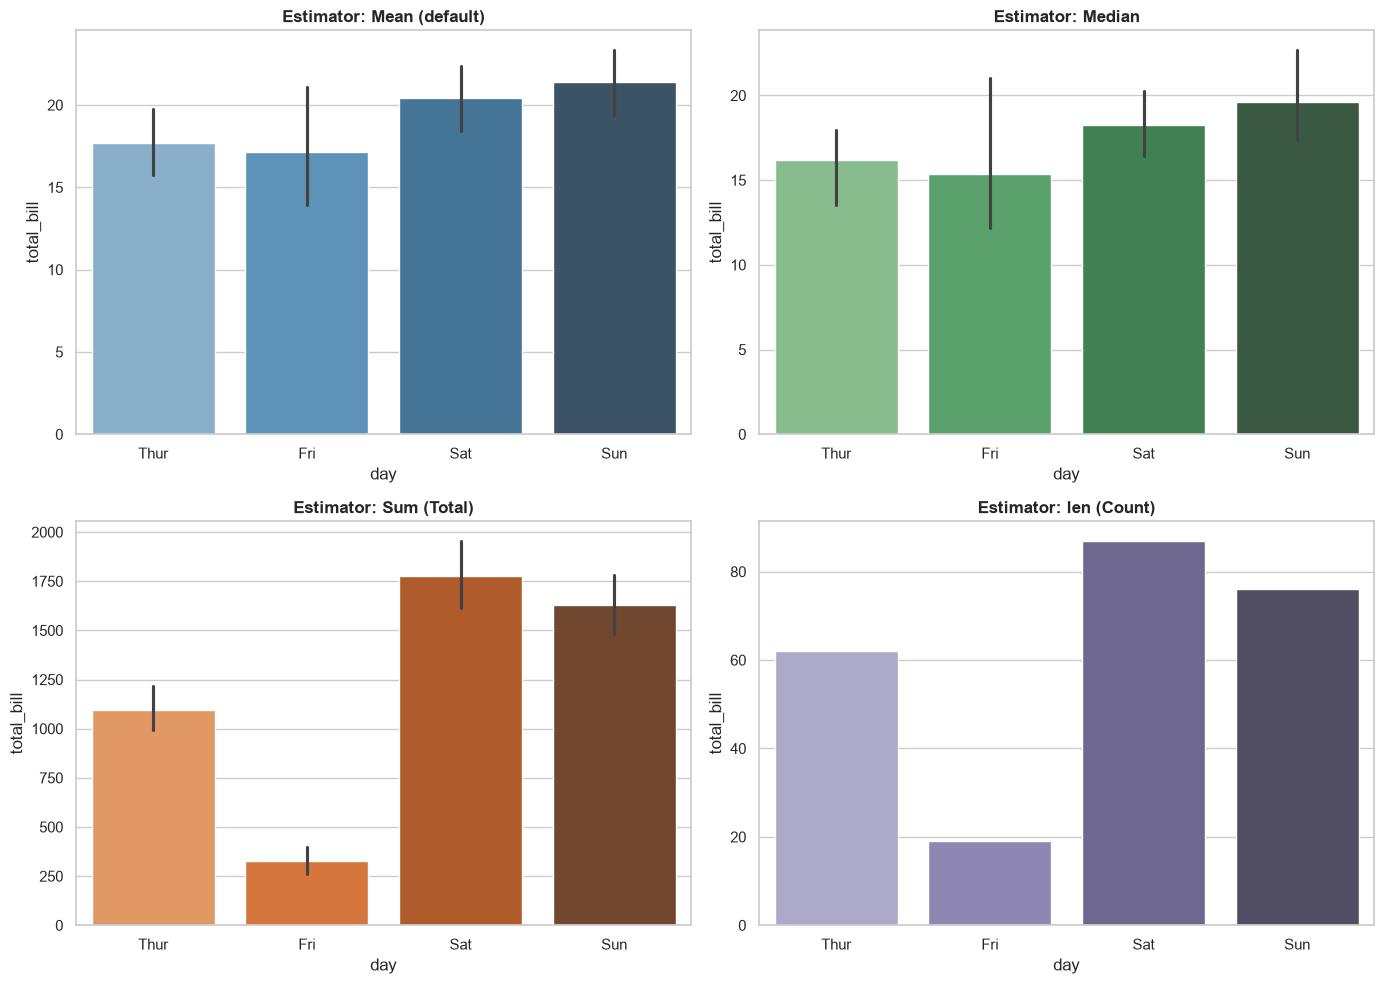

In [3]:
# Compare different estimators
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mean
sns.barplot(data=tips, x='day', y='total_bill', estimator=np.mean, ax=axes[0,0], palette='Blues_d')
axes[0,0].set_title('Estimator: Mean (default)', fontweight='bold')

# Median
sns.barplot(data=tips, x='day', y='total_bill', estimator=np.median, ax=axes[0,1], palette='Greens_d')
axes[0,1].set_title('Estimator: Median', fontweight='bold')

# Sum
sns.barplot(data=tips, x='day', y='total_bill', estimator=np.sum, ax=axes[1,0], palette='Oranges_d')
axes[1,0].set_title('Estimator: Sum (Total)', fontweight='bold')

# Count
sns.barplot(data=tips, x='day', y='total_bill', estimator=len, ax=axes[1,1], palette='Purples_d')
axes[1,1].set_title('Estimator: len (Count)', fontweight='bold')

plt.tight_layout()
save_fig('../exports/10_statistical/estimator_comparison.png')
plt.show()

## 2️⃣ Error Bar Options: `errorbar` Parameter

**Options:**
- `"ci"` - Confidence interval (default: 95%)
- `("ci", 99)` - Custom CI level
- `"sd"` - Standard deviation
- `"se"` - Standard error
- `("pi", 95)` - Prediction interval
- `None` - No error bars

✅ Plot saved to ../exports/10_statistical/errorbar_types.png


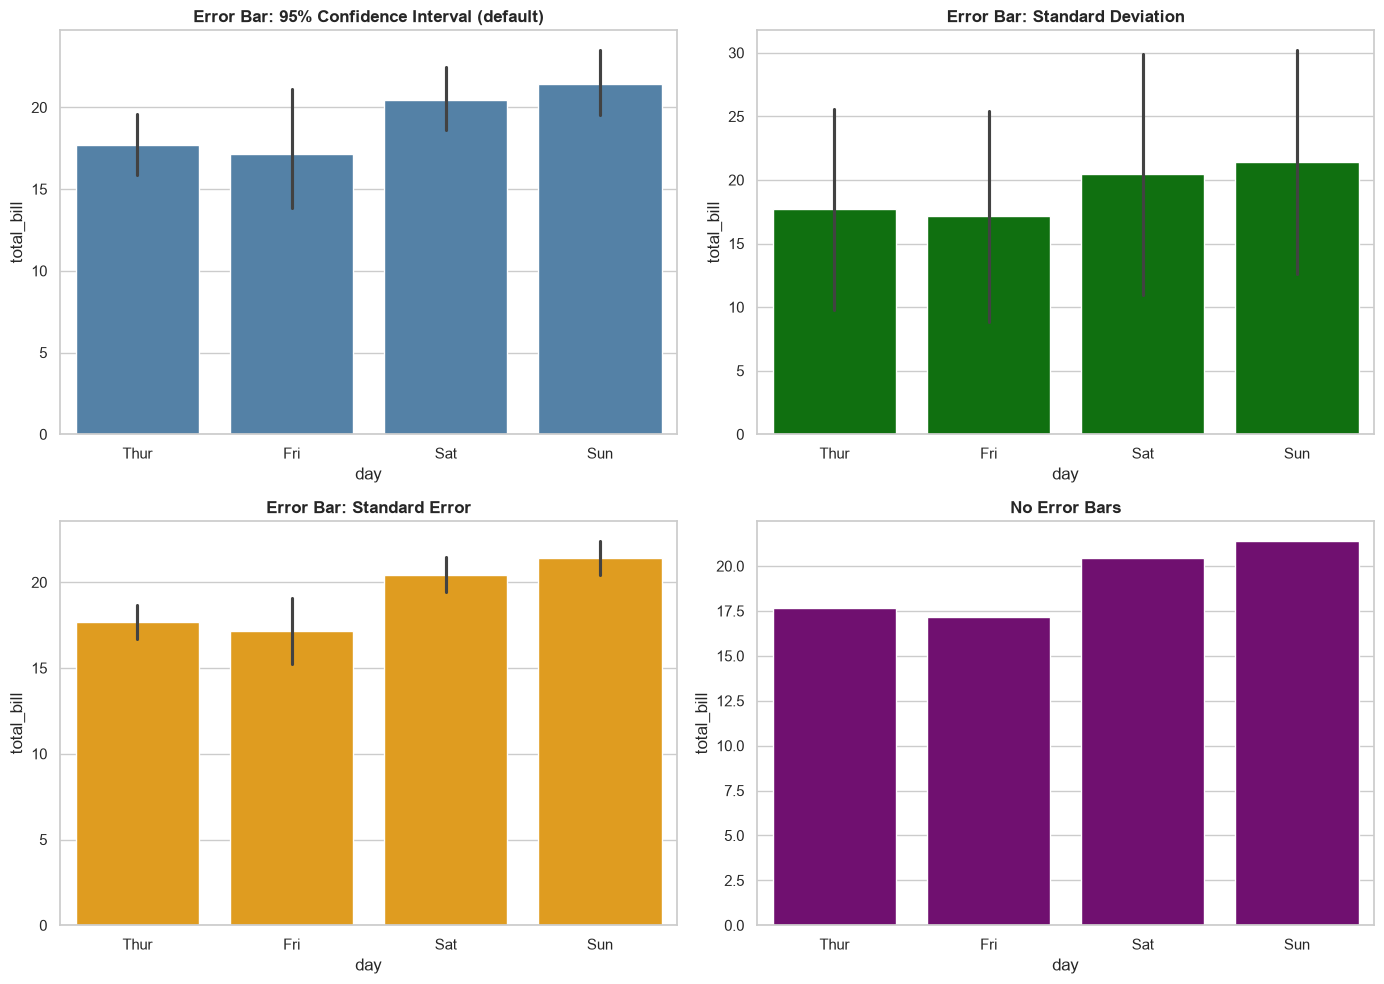

In [4]:
# Compare error bar types
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 95% CI
sns.barplot(data=tips, x='day', y='total_bill', errorbar='ci', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Error Bar: 95% Confidence Interval (default)', fontweight='bold')

# Standard Deviation
sns.barplot(data=tips, x='day', y='total_bill', errorbar='sd', ax=axes[0,1], color='green')
axes[0,1].set_title('Error Bar: Standard Deviation', fontweight='bold')

# Standard Error
sns.barplot(data=tips, x='day', y='total_bill', errorbar='se', ax=axes[1,0], color='orange')
axes[1,0].set_title('Error Bar: Standard Error', fontweight='bold')

# No error bars
sns.barplot(data=tips, x='day', y='total_bill', errorbar=None, ax=axes[1,1], color='purple')
axes[1,1].set_title('No Error Bars', fontweight='bold')

plt.tight_layout()
save_fig('../exports/10_statistical/errorbar_types.png')
plt.show()

## 3️⃣ Custom Estimator Functions

Create functions that return single aggregated values.

/var/folders/b1/_jgsd68x1ll8qj42cvtdmyvh0000gn/T/ipykernel_52921/2713256968.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=employee_df, x='Department', y='Salary',
/var/folders/b1/_jgsd68x1ll8qj42cvtdmyvh0000gn/T/ipykernel_52921/2713256968.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
/var/folders/b1/_jgsd68x1ll8qj42cvtdmyvh0000gn/T/ipykernel_52921/2713256968.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=employee_df, x='Department', y='Salary',
/var/folders/b1/_jgsd68x1ll8qj42cvt

✅ Plot saved to ../exports/10_statistical/custom_estimators.png


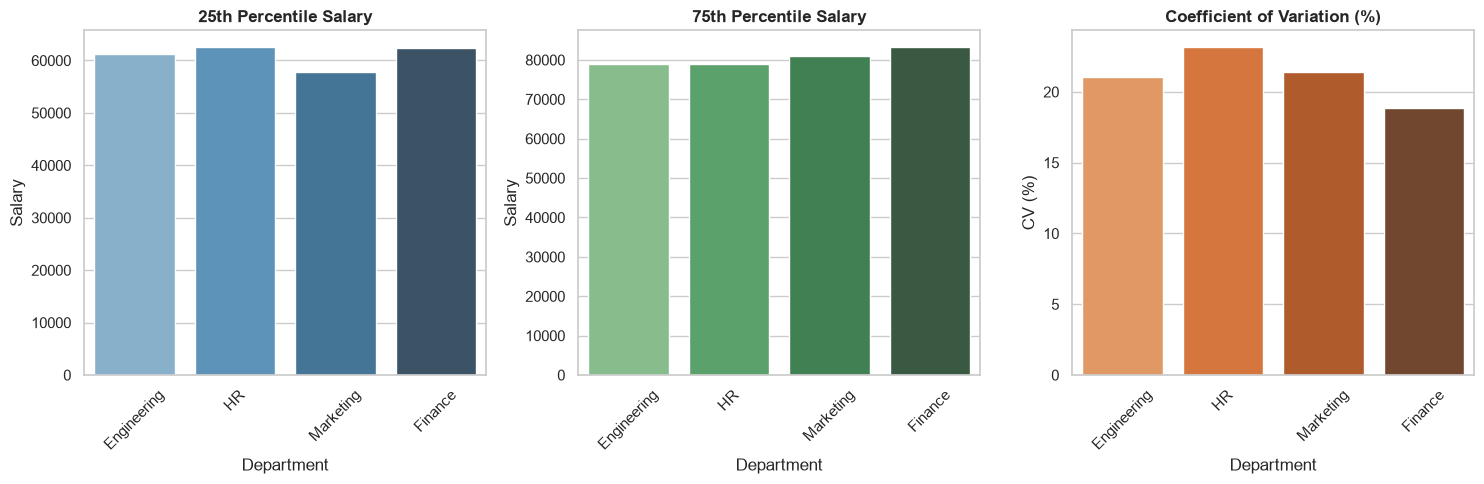

In [5]:
# Custom estimators
def percentile_25(x):
    return np.percentile(x, 25)

def percentile_75(x):
    return np.percentile(x, 75)

def coefficient_of_variation(x):
    return (np.std(x) / np.mean(x)) * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 25th percentile
sns.barplot(data=employee_df, x='Department', y='Salary', 
            estimator=percentile_25, errorbar=None, ax=axes[0], palette='Blues_d')
axes[0].set_title('25th Percentile Salary', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# 75th percentile
sns.barplot(data=employee_df, x='Department', y='Salary', 
            estimator=percentile_75, errorbar=None, ax=axes[1], palette='Greens_d')
axes[1].set_title('75th Percentile Salary', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

# Coefficient of Variation
sns.barplot(data=employee_df, x='Department', y='Salary', 
            estimator=coefficient_of_variation, errorbar=None, ax=axes[2], palette='Oranges_d')
axes[2].set_title('Coefficient of Variation (%)', fontweight='bold')
axes[2].set_ylabel('CV (%)')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)

plt.tight_layout()
save_fig('../exports/10_statistical/custom_estimators.png')
plt.show()

## 🎯 Summary

### **Key Takeaways:**

1. **Estimator Parameter:**
   - Controls how data is aggregated before plotting
   - Default: `np.mean`
   - Works with: `barplot()`, `pointplot()`, `lineplot()`
   - Can use any function that returns a single value

2. **Error Bar Options:**
   - `"ci"`: Confidence interval (uncertainty in mean estimate)
   - `"sd"`: Standard deviation (data spread)
   - `"se"`: Standard error (precision of mean)
   - `("pi", 95)`: Prediction interval (future observation range)

3. **When to Use Which:**
   - **CI**: Show uncertainty in the estimated mean
   - **SD**: Show variability in the data
   - **SE**: Show precision of the mean estimate
   - **None**: When error bars would clutter the plot

4. **Custom Estimators:**
   - Create functions for specialized aggregations
   - Examples: percentiles, CV, range, custom formulas
   - Must return a single numeric value

5. **Best Practices:**
   - Always specify what your error bars represent
   - Use CI for statistical inference
   - Use SD to show data variability
   - Choose estimators that match your question

### **Decision Guide:**

| Question | Estimator | Error Bar |
|----------|-----------|----------|
| What's the typical value? | `np.mean` or `np.median` | `"ci"` |
| What's the total? | `np.sum` | None |
| How variable is the data? | `np.mean` | `"sd"` |
| How precise is our estimate? | `np.mean` | `"se"` |
| What's the 90th percentile? | Custom (percentile) | None or `"ci"` |